## Introduction

In this project, we will be exploring binary classification and regression modeling using decision trees with the `Indian Graduate Admissions` dataset provided by `Kaggle`

## Dataset

This dataset primarily contains features that are used in determining admission to graduate degree programs, with the complete list of features summarized below:

- `GRE Scores` (Out of 350)
- `TOEFL Scores` (Out of 120)
- `University Rating` (Out of 5)
- `Statement of Purpose and Letter of Recommendation Strength` (Out of 5)
- `Undergraduate GPA` (Out of 10)
- `Research Experience` (Binary)
- `Chance of Admit` (Ranging from 0 to 1)

In [ ]:
# Installing necessary packages and modules into virtual environment
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

In [17]:
# Importing the necessary packages and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

%matplotlib inline

## Decision Trees for Classification

The first thing that we need to do before anything else, is load our `Admission_Predict` csv file into a Pandas DataFrame.

In addition to this, we will also clean up the column names a little bit.

In [18]:
# Creating a Pandas DataFrame
df = pd.read_csv("Admission_Predict.csv")

# Cleaning column names
df.columns = df.columns.str.strip().str.replace(' ','_').str.lower()

The next thing that we will do is we will create a binary class from the `chance_of_admit` columnn (1 = admission likely, 0 = admission unlikely).

For this instance, we will consider a value greater than 0.8 (80%) as likely to be admitted.

The remaining columns in our dataset will be used as predictor variables.

In [19]:
# Defining our predictors and binary class
X = df.loc[:,'gre_score':'research']
y = df['chance_of_admit']>=.8

The next step that we will take is we will use the `sklearn` `tree` module to create, train, predict, and visualize a decision tree classifier.

This is relatively the same as using any other kind of `sklearn` model.

In [20]:
# Creating our Decision Tree Classifier
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, 
                                                    test_size=0.2)
dt = DecisionTreeClassifier(max_depth=2, ccp_alpha=0.01, criterion='gini')
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

# Printing Score and Accuracy Score
print(dt.score(x_test, y_test))
print(accuracy_score(y_test, y_pred))

0.925
0.925


The next thing that we would like to do is to visualize our decision tree.

In this project, we will be using the `export_text` method from the `sklearn` `tree` module.

Note that there are other ways to create a visualization of a decision tree, but this is the method that will be used for this project.

|--- cgpa <= 8.85
|   |--- class: False
|--- cgpa >  8.85
|   |--- gre_score <= 313.50
|   |   |--- class: False
|   |--- gre_score >  313.50
|   |   |--- class: True



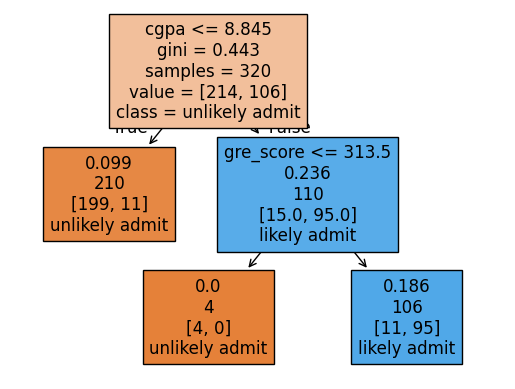

In [22]:
# Plotting and Visualizing our Tree
tree.plot_tree(dt, feature_names = x_train.columns, 
               max_depth=3, class_names = ['unlikely admit', 'likely admit'], 
               label='root', filled=True)

# Printing the visual
print(tree.export_text(dt, feature_names = X.columns.tolist()))

A couple things to note in the above results:

1. For any classification task, the default split criteria is the `Gini Imputiry` - which essentially gives us some insight into how impure our groupings are.

2. At the root node, the first split is chosen as the split that will maximize the information gain, which is also what decreases the Gini Impurity the most, leading to a more pure grouping arrangement.

3. Also, we want to begin to investigate how the initial split of `cgpa<=8.85` is actually determined. Here, `cgpa` is a continuous variable which can make this a bit more complicated, as the split technically could occur at any value of `cgpa`.

To verify initially that this initial split does maximize information gain and minimizes gini impurity, we will use the functions `gini` and `info_gain`.

Note that we are manually defining these functions.